# Baseline Riemanniano para Clasificacion EEG

In [54]:
try:
    import pyriemann
    import pywt
except ImportError:
    import subprocess, sys
    if not hasattr(sys, 'pyriemann'):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyriemann'])
    if not hasattr(sys, 'pywt'):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'PyWavelets'])
    raise SystemExit('Dependencias instaladas. Reinicia el kernel y vuelve a ejecutar.')

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.base import clone
import pywt

from pyriemann.estimation import Covariances
from pyriemann.classification import MDM, FgMDM
from pyriemann.tangentspace import TangentSpace
from pyriemann.utils.mean import mean_riemann

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk', font_scale=1.2)

## Configuracion

In [59]:
DATA_DIR = Path('../data/preprocessed')

SUBJECT = 'S01'
SUBJECTS_ALL = None

ONLY_IMAGINED = True
ONLY_CLEAN = False

TARGET_IDX = 1
SUBSETS = None

N_SEEDS = 5
K_FOLDS = 5
SEEDS_LIST = [42, 17, 123, 256, 999]

channel_names = ['F3', 'F4', 'C3', 'C4', 'P3', 'P4']
band_names = ['delta', 'theta', 'alpha', 'sigma', 'beta', 'gamma']

## Helpers: carga, filtrado, DWT

In [60]:
def load_subjects(data_dir, subject_list=None):
    if subject_list is None:
        files = sorted(data_dir.glob('S*_preprocessed.npz'))
    else:
        files = [data_dir / f'{s}_preprocessed.npz' for s in subject_list]
    
    X_parts, Y_parts = [], []
    subj_map = []
    
    for f in files:
        d = np.load(f)
        X_parts.append(d['x'])
        Y_parts.append(d['y'])
        subj_map.extend([f.stem] * len(d['y']))
    
    return np.concatenate(X_parts, axis=0), np.concatenate(Y_parts, axis=0), subj_map

def filter_trials(X, Y, only_imagined=False, only_clean=False):
    mask = np.ones(len(Y), dtype=bool)
    if only_imagined:
        mask &= (Y[:, 0] == 1)
    if only_clean:
        mask &= (Y[:, 2] == 1)
    return X[mask], Y[mask]

def select_target(Y, target_idx):
    labels = Y[:, target_idx].astype(int)
    return labels - labels.min()

def build_subsets(target_idx, subsets_cfg=None):
    if target_idx != 1:
        return [('todos', None, None)]
    
    if subsets_cfg is None:
        subsets_cfg = ['vocales', 'comandos']
    
    stim_map = {
        'vocales': ((1, 5), ['A', 'E', 'I', 'O', 'U']),
        'comandos': ((6, 11), ['up', 'down', 'left', 'right', 'fwd', 'back']),
    }
    
    result = []
    for s in subsets_cfg:
        if s is None:
            result.append(('todos', None, None))
        elif s in stim_map:
            rng, names = stim_map[s]
            result.append((s, rng, names))
        else:
            raise ValueError(f'Subset desconocido: {s}')
    return result

def quasi_dwt_decomposition(channel_data, wavelet_name='db4'):
    cA, cD = pywt.dwt(channel_data, wavelet_name, mode='periodization')
    gamma = cD
    coeffs = pywt.swt(cA, wavelet_name, level=3, start_level=0)
    cA3_swt, cD3_swt = coeffs[0]
    cA2_swt, cD2_swt = coeffs[1]
    cA1_swt, cD1_swt = coeffs[2]
    delta = cA3_swt
    theta = cD3_swt
    beta = cD1_swt
    coeffs_alpha_sigma = pywt.swt(cD2_swt, wavelet_name, level=1, start_level=0)
    alpha = coeffs_alpha_sigma[0][0]
    sigma = coeffs_alpha_sigma[0][1]
    A = np.vstack([delta, theta, alpha, sigma, beta, gamma])
    return A

def transform_dwt(X):
    n_trials, n_ch, n_samples = X.shape
    n_bands = 6
    band_len = n_samples // 2
    n_pseudo_ch = n_ch * n_bands
    X_dwt = np.zeros((n_trials, n_pseudo_ch, band_len))
    
    for t in range(n_trials):
        for c in range(n_ch):
            bands = quasi_dwt_decomposition(X[t, c])
            X_dwt[t, c * n_bands:(c + 1) * n_bands, :] = bands
    
    return X_dwt

target_names = {0: 'Modalidad', 1: 'Estimulo', 2: 'Artefacto'}

clf_templates = {
    'MDM': MDM(metric='riemann'),
    'TSM + SVM': make_pipeline(TangentSpace(metric='riemann'), SVC(kernel='linear', C=1.0)),
    'FgMDM': FgMDM(metric='riemann'),
}

def run_cv(cov, labels, clf_templates, seeds_list, k_folds):
    cv_results = {name: [] for name in clf_templates.keys()}
    for seed in seeds_list:
        skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
        for train_idx, test_idx in skf.split(cov, labels):
            cov_tr, cov_te = cov[train_idx], cov[test_idx]
            y_tr, y_te = labels[train_idx], labels[test_idx]
            for name, clf_tpl in clf_templates.items():
                clf = clone(clf_tpl)
                clf.fit(cov_tr, y_tr)
                cv_results[name].append(accuracy_score(y_te, clf.predict(cov_te)))
    return cv_results

def run_split(X, cov, labels, clf_templates, seed=42):
    X_train, X_test, cov_train, cov_test, y_train, y_test = train_test_split(
        X, cov, labels, test_size=0.2, random_state=seed, stratify=labels
    )
    split_results = {}
    for name, clf_tpl in clf_templates.items():
        clf = clone(clf_tpl)
        clf.fit(cov_train, y_train)
        y_pred = clf.predict(cov_test)
        acc = accuracy_score(y_test, y_pred)
        split_results[name] = {'accuracy': acc, 'y_true': y_test, 'y_pred': y_pred}
    return split_results

print('Funciones definidas correctamente')

Funciones definidas correctamente


## 1. Carga y filtrado de datos

In [61]:
if SUBJECT is not None:
    subj_list = [SUBJECT]
else:
    subj_list = SUBJECTS_ALL

X_all, Y_all, subj_map_all = load_subjects(DATA_DIR, subj_list)
X_all, Y_all = filter_trials(X_all, Y_all, only_imagined=ONLY_IMAGINED, only_clean=ONLY_CLEAN)
subset_defs = build_subsets(TARGET_IDX, SUBSETS)

print(f'Cargados: {len(X_all)} trials de {len(set(subj_map_all))} sujetos')
print(f'Target: {target_names[TARGET_IDX]}')
print(f'Subsets a analizar: {[s[0] for s in subset_defs]}')
print(f'X shape: {X_all.shape}')

Cargados: 578 trials de 1 sujetos
Target: Estimulo
Subsets a analizar: ['vocales', 'comandos']
X shape: (578, 6, 512)


## 2. Analisis por subset (raw + DWT)

In [63]:
subset_results = {}

for subset_name, stim_range, class_names in subset_defs:
    print(f'\n{"=" * 60}')
    print(f'SUBSET: {subset_name}')
    print(f'{"=" * 60}')
    
    if stim_range is not None:
        lo, hi = stim_range
        mask = (Y_all[:, 1].astype(int) >= lo) & (Y_all[:, 1].astype(int) <= hi)
    else:
        mask = np.ones(len(Y_all), dtype=bool)
    
    X_s = X_all[mask]
    Y_s = Y_all[mask]
    labels = select_target(Y_s, TARGET_IDX)
    n_classes = len(np.unique(labels))
    chance = 1.0 / n_classes
    
    if class_names is None:
        class_names = [f'C{i}' for i in range(n_classes)]
    
    print(f'Trials: {len(X_s)} | Clases: {n_classes} | Chance: {chance:.1%}')
    
    cov_raw = Covariances(estimator='lwf').fit_transform(X_s)
    
    X_dwt = transform_dwt(X_s)
    cov_dwt = Covariances(estimator='lwf').fit_transform(X_dwt)
    
    print(f'Cov raw: {cov_raw.shape} | Cov DWT: {cov_dwt.shape}')
    
    unique_cls, counts = np.unique(labels, return_counts=True)
    for c, cnt in zip(unique_cls, counts):
        print(f'  Clase {c} ({class_names[c]}): {cnt} trials')
    
    split_raw = run_split(X_s, cov_raw, labels, clf_templates)
    split_dwt = run_split(X_dwt, cov_dwt, labels, clf_templates)
    
    cv_raw = run_cv(cov_raw, labels, clf_templates, SEEDS_LIST, K_FOLDS)
    cv_dwt = run_cv(cov_dwt, labels, clf_templates, SEEDS_LIST, K_FOLDS)
    
    subset_results[subset_name] = {
        'n_classes': n_classes,
        'chance': chance,
        'class_names': class_names,
        'cov_raw': cov_raw,
        'cov_dwt': cov_dwt,
        'X_raw': X_s,
        'X_dwt': X_dwt,
        'labels': labels,
        'split_raw': split_raw,
        'split_dwt': split_dwt,
        'cv_raw': cv_raw,
        'cv_dwt': cv_dwt,
    }
    
    for pipeline_name, cv_r in [('raw', cv_raw), ('DWT', cv_dwt)]:
        print(f'\n  Pipeline {pipeline_name}:')
        for name, accs in cv_r.items():
            arr = np.array(accs)
            print(f'  {name:12s} | {arr.mean():.1%} +/- {arr.std():.1%} | {arr.min():.1%}-{arr.max():.1%}')


SUBSET: vocales
Trials: 274 | Clases: 5 | Chance: 20.0%
Cov raw: (274, 6, 6) | Cov DWT: (274, 36, 36)
  Clase 0 (A): 56 trials
  Clase 1 (E): 53 trials
  Clase 2 (I): 55 trials
  Clase 3 (O): 55 trials
  Clase 4 (U): 55 trials

  Pipeline raw:
  MDM          | 22.6% +/- 5.8% | 12.7%-38.2%
  TSM + SVM    | 21.9% +/- 4.9% | 10.9%-30.9%
  FgMDM        | 22.4% +/- 3.5% | 14.5%-27.8%

  Pipeline DWT:
  MDM          | 20.1% +/- 4.7% | 10.9%-30.9%
  TSM + SVM    | 20.5% +/- 4.5% | 10.9%-29.1%
  FgMDM        | 18.5% +/- 4.5% | 12.7%-29.1%

SUBSET: comandos
Trials: 304 | Clases: 6 | Chance: 16.7%
Cov raw: (304, 6, 6) | Cov DWT: (304, 36, 36)
  Clase 0 (up): 51 trials
  Clase 1 (down): 51 trials
  Clase 2 (left): 51 trials
  Clase 3 (right): 51 trials
  Clase 4 (fwd): 51 trials
  Clase 5 (back): 49 trials

  Pipeline raw:
  MDM          | 12.6% +/- 3.9% | 6.6%-23.0%
  TSM + SVM    | 12.9% +/- 5.0% | 3.3%-24.6%
  FgMDM        | 12.7% +/- 4.0% | 4.9%-23.0%

  Pipeline DWT:
  MDM          | 12.3% 

## 3. Matrices de confusion (split unico, raw y DWT)

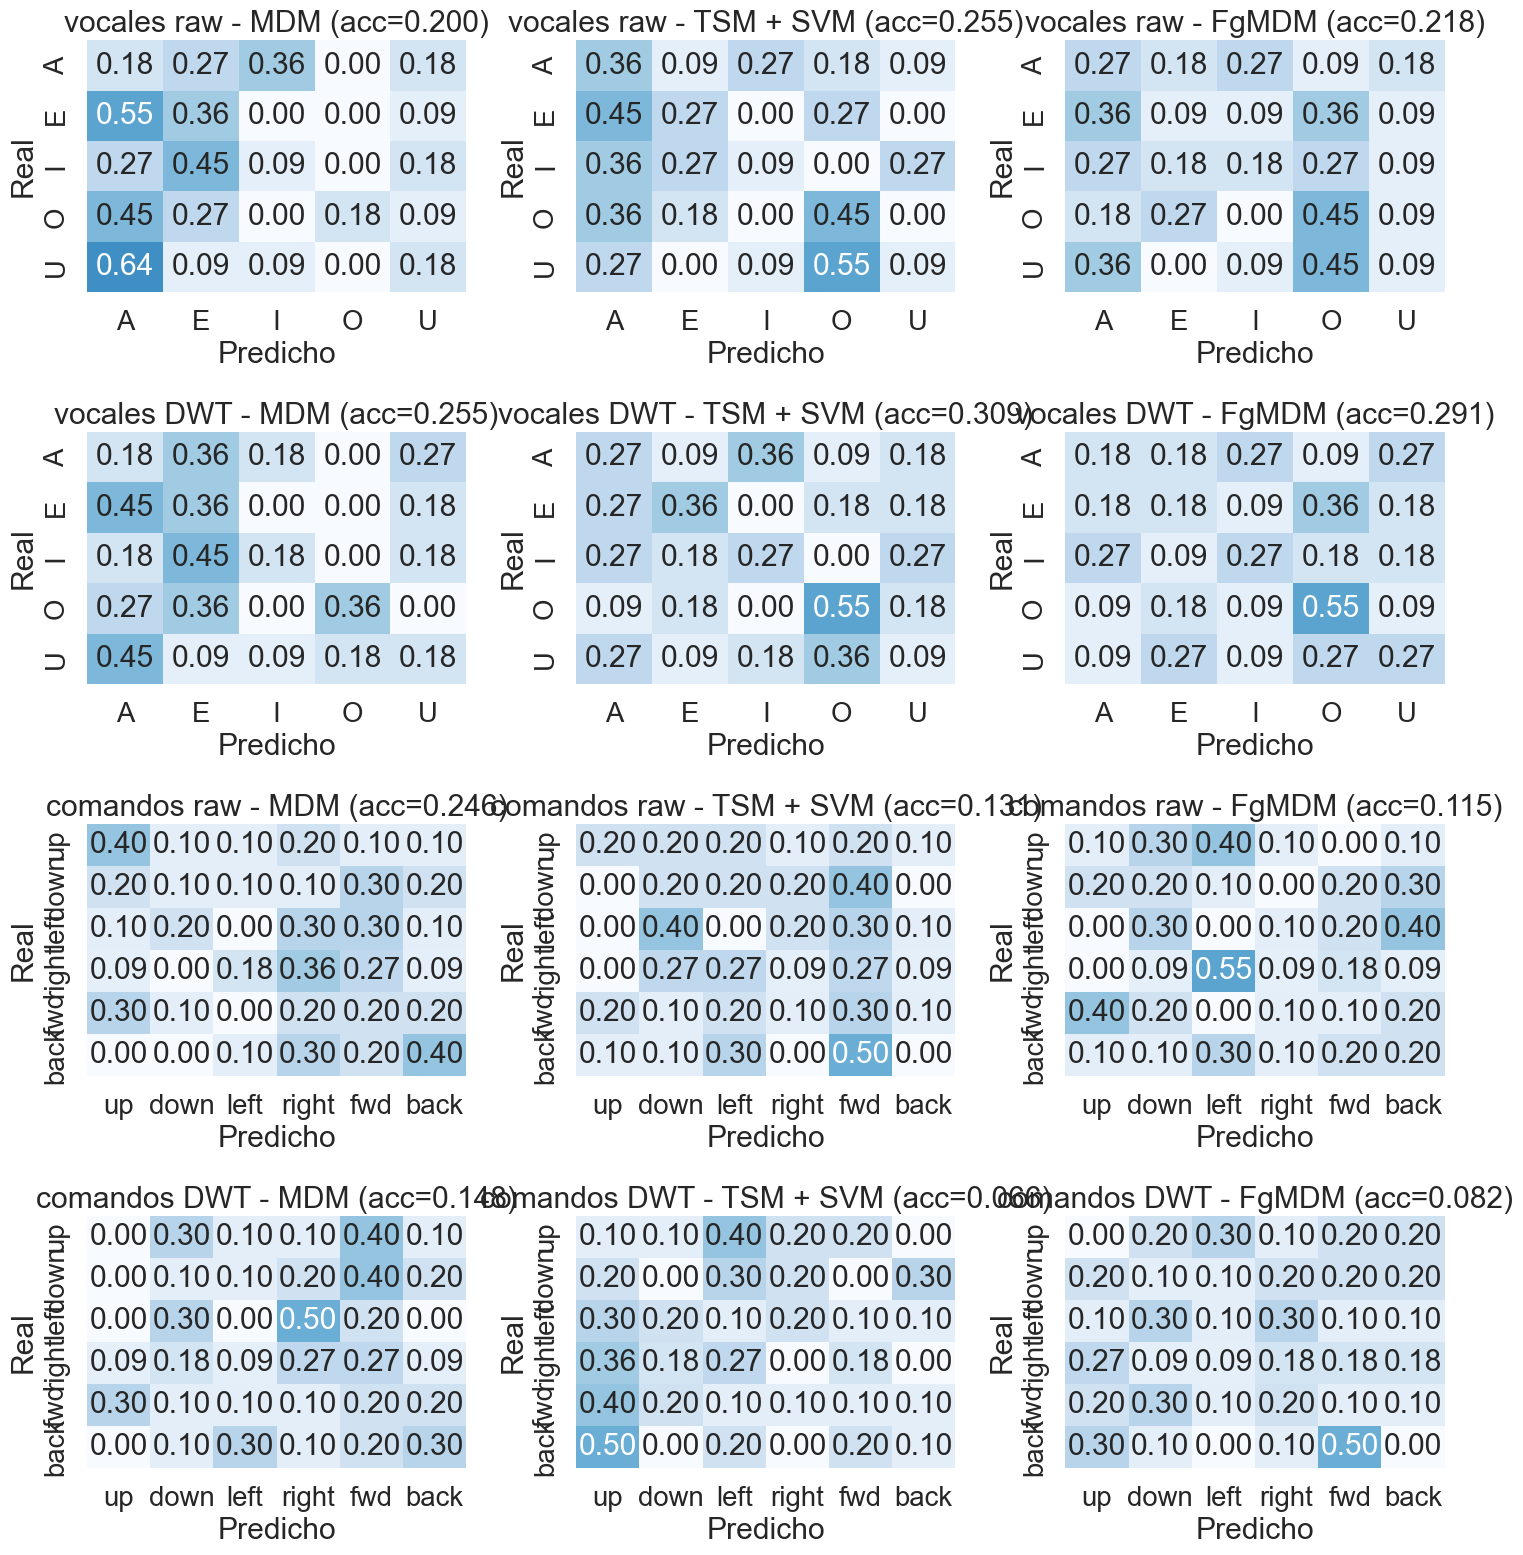

In [64]:
n_subsets = len(subset_results)
n_clf = len(clf_templates)

fig, axes = plt.subplots(n_subsets * 2, n_clf, figsize=(5 * n_clf, 4 * n_subsets * 2))
if axes.ndim == 1:
    axes = axes.reshape(-1, n_clf)

for row_start, (sname, sdata) in enumerate(subset_results.items()):
    class_names = sdata['class_names']
    for pipeline_name, splits in [('raw', sdata['split_raw']), ('DWT', sdata['split_dwt'])]:
        row = row_start * 2 + (0 if pipeline_name == 'raw' else 1)
        for col, (name, res) in enumerate(splits.items()):
            cm = confusion_matrix(res['y_true'], res['y_pred'], labels=range(sdata['n_classes']))
            cm_norm = cm / cm.sum(axis=1, keepdims=True)
            ax = axes[row, col]
            sns.heatmap(cm_norm, cmap='Blues', ax=ax, annot=True, fmt='.2f', cbar=False, vmin=0, vmax=1)
            ax.set_title(f'{sname} {pipeline_name} - {name} (acc={res["accuracy"]:.3f})')
            ax.set_xticklabels(class_names)
            ax.set_yticklabels(class_names)
            ax.set_xlabel('Predicho')
            ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 4. Boxplots de validacion cruzada por subset

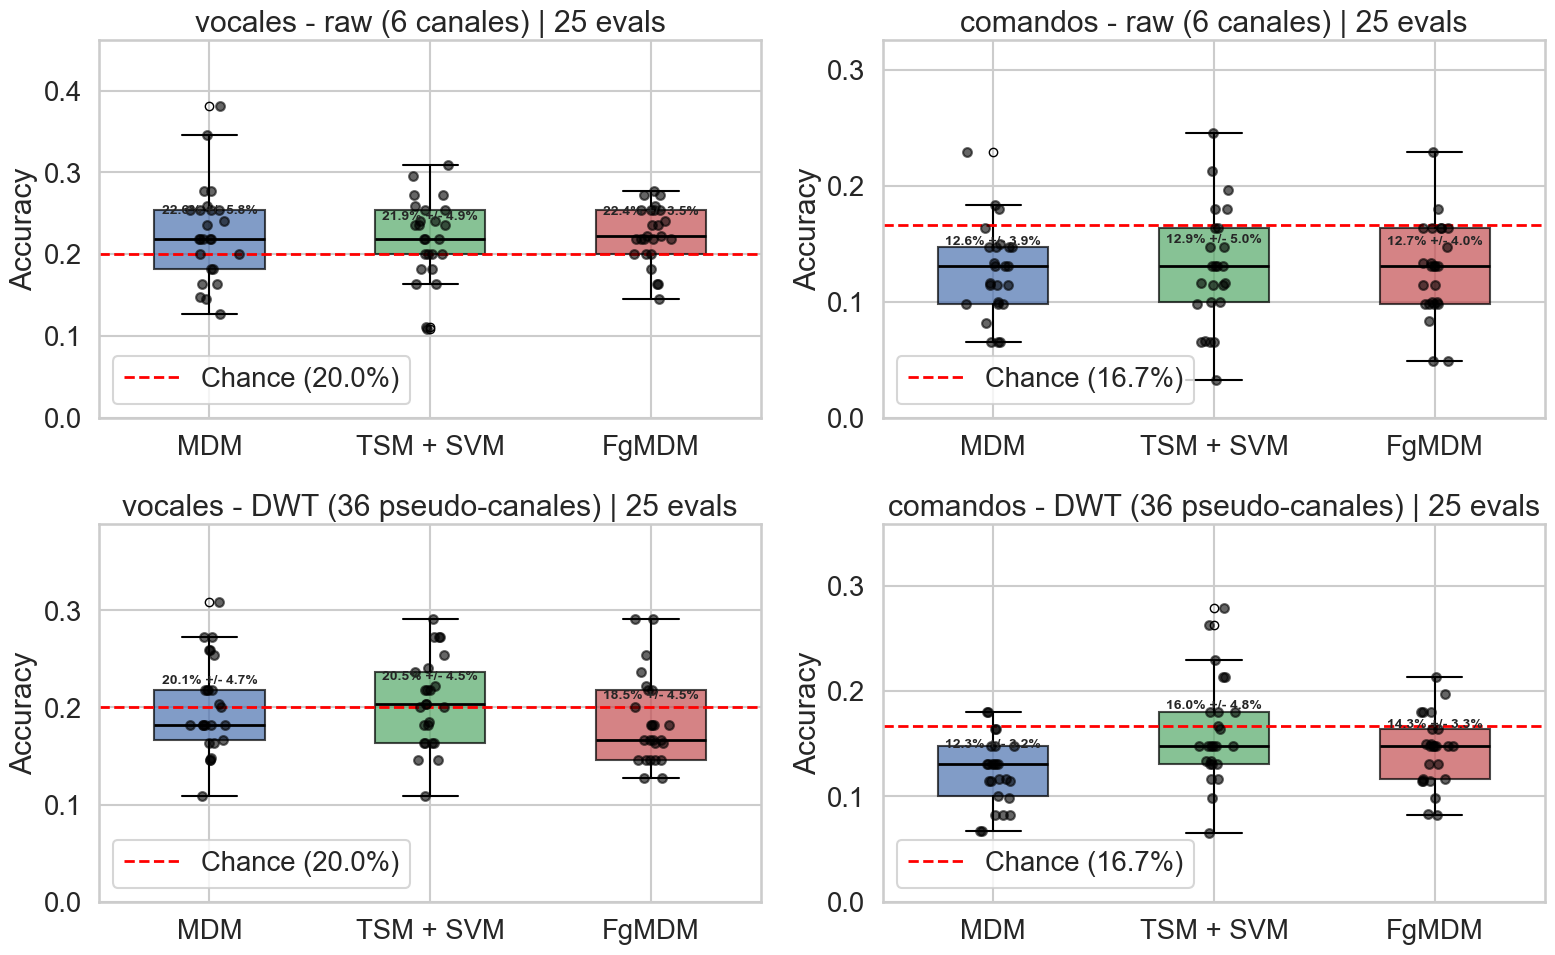

In [68]:
def plot_boxplot_with_points(cv_results, clf_names, chance, title, ax):
    colors = ['#4C72B0', '#55A868', '#C44E52']
    data_to_plot = [cv_results[name] for name in clf_names]
    
    bp = ax.boxplot(data_to_plot, labels=clf_names, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for i, name in enumerate(clf_names, 1):
        accs = cv_results[name]
        x = np.random.normal(i, 0.04, size=len(accs))
        ax.scatter(x, accs, color='black', alpha=0.6, s=40, zorder=3)
    
    ax.axhline(y=chance, color='red', linestyle='--', linewidth=2, label=f'Chance ({chance:.1%})')
    
    for i, name in enumerate(clf_names, 1):
        accs = np.array(cv_results[name])
        ax.text(i, accs.mean() + 0.02, f'{accs.mean():.1%} +/- {accs.std():.1%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    all_vals = [v for lst in data_to_plot for v in lst]
    ax.set_ylim(0.0, min(1.0, max(all_vals) + 0.08))
    ax.set_title(title)
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower left')

clf_names = list(clf_templates.keys())

fig, axes = plt.subplots(2, n_subsets, figsize=(8 * n_subsets, 10))
axes = np.atleast_2d(axes)

for col, (sname, sdata) in enumerate(subset_results.items()):
    plot_boxplot_with_points(
        sdata['cv_raw'], clf_names, sdata['chance'],
        f'{sname} - raw (6 canales) | {N_SEEDS * K_FOLDS} evals',
        axes[0, col]
    )
    plot_boxplot_with_points(
        sdata['cv_dwt'], clf_names, sdata['chance'],
        f'{sname} - DWT (36 pseudo-canales) | {N_SEEDS * K_FOLDS} evals',
        axes[1, col]
    )

plt.tight_layout()
plt.show()

## 5. Comparacion directa raw vs DWT

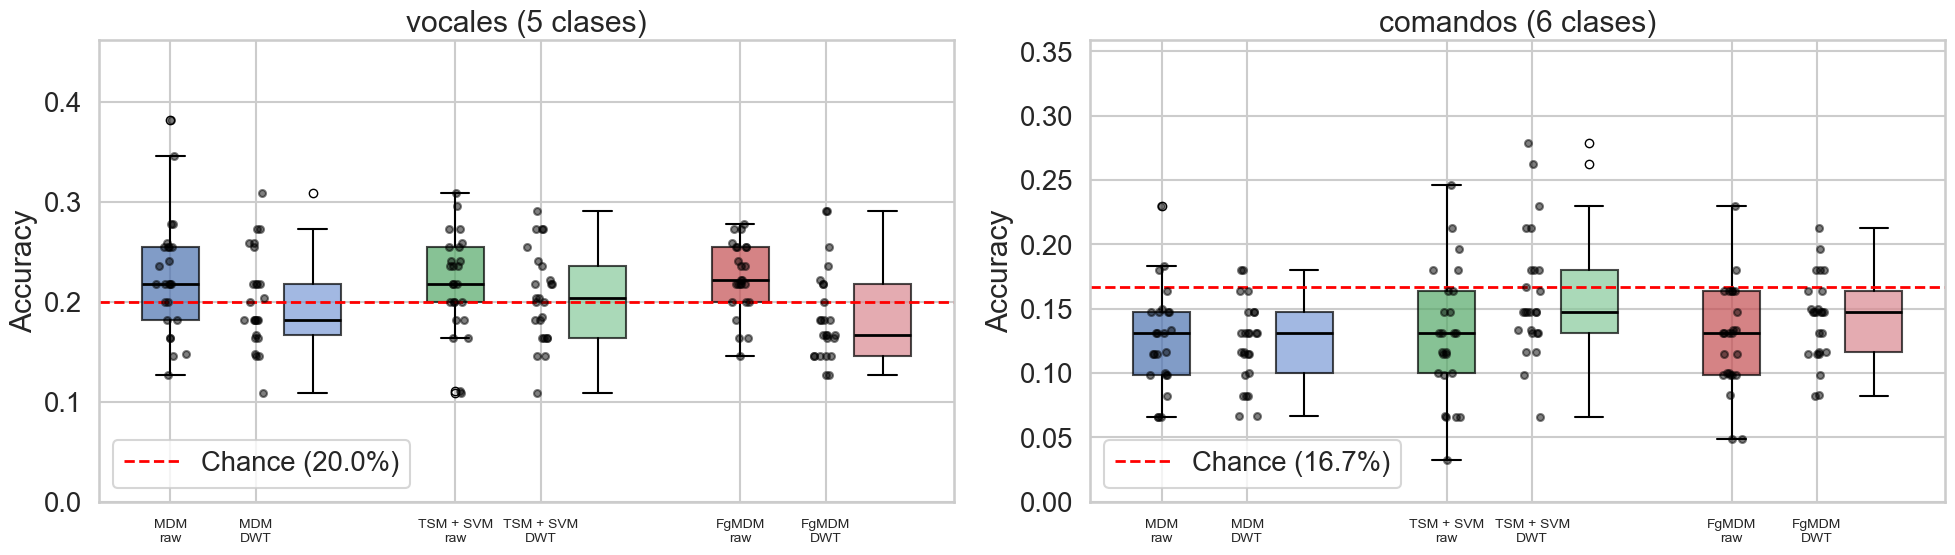

In [69]:
n_subsets = len(subset_results)
fig, axes = plt.subplots(1, n_subsets, figsize=(10 * n_subsets, 6))
if n_subsets == 1:
    axes = [axes]

colors_raw = ['#4C72B0', '#55A868', '#C44E52']
colors_dwt = ['#7B9AD6', '#87C99A', '#D98890']

for idx, (sname, sdata) in enumerate(subset_results.items()):
    ax = axes[idx]
    chance = sdata['chance']
    
    positions = []
    labels_list = []
    data_list = []
    color_list = []
    
    pos = 1
    for clf_i, clf_name in enumerate(clf_names):
        positions.append(pos)
        labels_list.append(f'{clf_name}\nraw')
        data_list.append(sdata['cv_raw'][clf_name])
        color_list.append(colors_raw[clf_i])
        positions.append(pos + 0.6)
        labels_list.append(f'{clf_name}\nDWT')
        data_list.append(sdata['cv_dwt'][clf_name])
        color_list.append(colors_dwt[clf_i])
        pos += 2
    
    bp = ax.boxplot(data_list, patch_artist=True, widths=0.4,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_list, fontsize=10)
    
    for p, d in zip(positions, data_list):
        x = np.random.normal(p, 0.04, size=len(d))
        ax.scatter(x, d, color='black', alpha=0.5, s=25, zorder=3)
    
    ax.axhline(y=chance, color='red', linestyle='--', linewidth=2, label=f'Chance ({chance:.1%})')
    
    all_vals = [v for lst in data_list for v in lst]
    ax.set_ylim(0.0, min(1.0, max(all_vals) + 0.08))
    ax.set_title(f'{sname} ({sdata["n_classes"]} clases)')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

## 6. Medias Riemannianas por clase (raw vs DWT)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

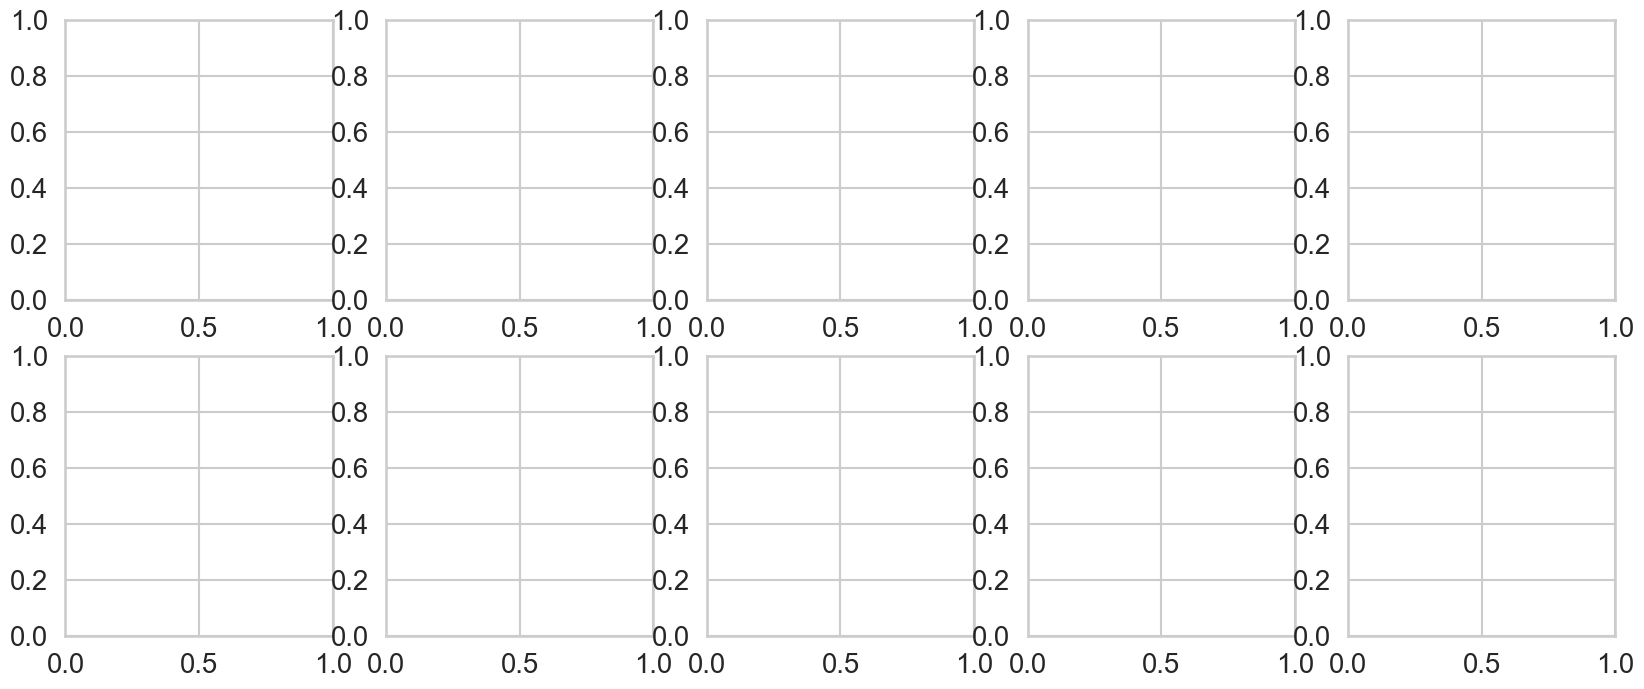

In [70]:
sname = list(subset_results.keys())[0]
sdata = subset_results[sname]
class_names = sdata['class_names']
labels = sdata['labels']
unique_cls = np.unique(labels)

fig, axes = plt.subplots(2, len(unique_cls), figsize=(4 * len(unique_cls), 8))

for i, c in enumerate(unique_cls):
    mean_raw = mean_riemann(sdata['cov_raw'][labels == c])
    mean_dwt = mean_riemann(sdata['cov_dwt'][labels == c])
    
    vmin_raw = np.log(np.array([sdata['cov_raw'][labels == j] for j in unique_cls])).min()
    vmax_raw = np.log(np.array([sdata['cov_raw'][labels == j] for j in unique_cls])).max()
    vmin_dwt = np.log(np.array([sdata['cov_dwt'][labels == j] for j in unique_cls])).min()
    vmax_dwt = np.log(np.array([sdata['cov_dwt'][labels == j] for j in unique_cls])).max()
    
    sns.heatmap(np.log(mean_raw), cmap='viridis', ax=axes[0, i],
                cbar=(i == len(unique_cls) - 1),
                vmin=vmin_raw, vmax=vmax_raw)
    axes[0, i].set_title(f'raw - {class_names[c]}')
    
    sns.heatmap(np.log(mean_dwt), cmap='viridis', ax=axes[1, i],
                cbar=(i == len(unique_cls) - 1),
                vmin=vmin_dwt, vmax=vmax_dwt)
    axes[1, i].set_title(f'DWT - {class_names[c]}')

axes[0, 0].set_ylabel('raw')
axes[1, 0].set_ylabel('DWT')
plt.suptitle(f'Medias Riemannianas por clase - {sname}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Analisis por sujeto (raw vs DWT)

In [71]:
subject_files = sorted(DATA_DIR.glob('S*_preprocessed.npz'))

subject_results = {sname: {'raw': {n: [] for n in clf_names}, 'DWT': {n: [] for n in clf_names}} for sname, _, _ in subset_defs}

for sf in subject_files:
    d = np.load(sf)
    X_s, Y_s = d['x'], d['y']
    X_s, Y_s = filter_trials(X_s, Y_s, only_imagined=ONLY_IMAGINED, only_clean=ONLY_CLEAN)
    
    for sname, stim_range, class_names in subset_defs:
        if stim_range is not None:
            lo, hi = stim_range
            mask = (Y_s[:, 1].astype(int) >= lo) & (Y_s[:, 1].astype(int) <= hi)
        else:
            mask = np.ones(len(Y_s), dtype=bool)
        
        lbls = select_target(Y_s[mask], TARGET_IDX)
        if len(np.unique(lbls)) < 2:
            continue
        
        X_m = X_s[mask]
        cov_r = Covariances(estimator='lwf').fit_transform(X_m)
        
        X_d = transform_dwt(X_m)
        cov_d = Covariances(estimator='lwf').fit_transform(X_d)
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        for pipeline_name, cov in [('raw', cov_r), ('DWT', cov_d)]:
            for name in clf_names:
                fold_accs = []
                for train_idx, test_idx in skf.split(cov, lbls):
                    cov_tr, cov_te = cov[train_idx], cov[test_idx]
                    y_tr, y_te = lbls[train_idx], lbls[test_idx]
                    clf = clone(clf_templates[name])
                    clf.fit(cov_tr, y_tr)
                    fold_accs.append(accuracy_score(y_te, clf.predict(cov_te)))
                subject_results[sname][pipeline_name][name].append(np.mean(fold_accs))
    
    print(f'{sf.stem}: {len(X_s)} trials tras filtrado')

S01_preprocessed: 578 trials tras filtrado
S02_preprocessed: 481 trials tras filtrado


KeyboardInterrupt: 

In [ ]:
n_subsets = len(subset_results)
fig, axes = plt.subplots(2, n_subsets, figsize=(8 * n_subsets, 10))
axes = np.atleast_2d(axes)

for col, (sname, sdata) in enumerate(subset_results.items()):
    n_subj = len(subject_results[sname]['raw'][clf_names[0]])
    
    plot_boxplot_with_points(
        subject_results[sname]['raw'], clf_names, sdata['chance'],
        f'{sname} - raw por sujeto (n={n_subj})',
        axes[0, col]
    )
    plot_boxplot_with_points(
        subject_results[sname]['DWT'], clf_names, sdata['chance'],
        f'{sname} - DWT por sujeto (n={n_subj})',
        axes[1, col]
    )

plt.tight_layout()
plt.show()

## 8. Resumen comparativo

In [ ]:
print(f'{"Subset":<12} | {"Pipeline":<6} | {"Clasificador":<12} | {"Media":>6s} | {"Std":>5s} | {"Min":>5s} | {"Max":>5s}')
print('-' * 75)

for sname, sdata in subset_results.items():
    for pipeline_name, cv_r in [('raw', sdata['cv_raw']), ('DWT', sdata['cv_dwt'])]:
        for name, accs in cv_r.items():
            arr = np.array(accs)
            print(f'{sname:<12} | {pipeline_name:<6} | {name:<12} | {arr.mean():>5.1%} | {arr.std():>4.1%} | {arr.min():>4.1%} | {arr.max():>4.1%}')
    print()